In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
file_path = "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)

Dataset shape: (3162, 11)


In [3]:
df.head()

,state,year,residential_billion_btu,commercial_billion_btu,industrial_billion_btu,transportation_billion_btu,co2_lag_1,co2_lag_2,energy_growth_rate,co2_growth_rate,co2_next_year
0,AK,1962,10472,7129,24859,34182,4.846,4.040,9.457298,9.925712,5.366
1,AK,1963,11256,9246,25598,32387,5.327,4.846,2.408601,0.732119,5.620
2,AK,1964,13004,12021,25522,32246,5.366,5.327,5.484915,4.733507,5.720
3,AK,1965,13857,14210,22874,34379,5.620,5.366,3.050983,1.779359,6.812
4,AK,1966,15563,15066,33619,36233,5.720,5.620,17.770954,19.090909,7.801


In [4]:
df.columns.tolist()

['state',
 'year',
 'residential_billion_btu',
 'commercial_billion_btu',
 'industrial_billion_btu',
 'transportation_billion_btu',
 'co2_lag_1',
 'co2_lag_2',
 'energy_growth_rate',
 'co2_growth_rate',
 'co2_next_year']

In [5]:
print(df.columns.tolist())
display(df.head(10))

['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate', 'co2_next_year']


,state,year,residential_billion_btu,commercial_billion_btu,industrial_billion_btu,transportation_billion_btu,co2_lag_1,co2_lag_2,energy_growth_rate,co2_growth_rate,co2_next_year
0,AK,1962,10472,7129,24859,34182,4.846,4.040,9.457298,9.925712,5.366
1,AK,1963,11256,9246,25598,32387,5.327,4.846,2.408601,0.732119,5.620
2,AK,1964,13004,12021,25522,32246,5.366,5.327,5.484915,4.733507,5.720
3,AK,1965,13857,14210,22874,34379,5.620,5.366,3.050983,1.779359,6.812
4,AK,1966,15563,15066,33619,36233,5.720,5.620,17.770954,19.090909,7.801
5,AK,1967,16413,17018,35332,43862,6.812,5.720,12.085867,14.518497,8.170
6,AK,1968,18203,18316,36296,47177,7.801,6.812,6.541176,4.730163,10.014
7,AK,1969,20544,25989,51183,56517,8.170,7.801,28.535236,22.570379,11.356
8,AK,1970,23650,28705,50729,76386,10.014,8.170,16.363660,13.401238,12.643
9,AK,1971,28350,31762,53265,85018,11.356,10.014,10.544938,11.333216,13.432


In [6]:
y = df["co2_next_year"]

In [7]:
X = df.drop(columns=["co2_next_year"])

In [8]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nYear range:")
print(df["year"].min(), "to", df["year"].max())


Shape: (3162, 11)

Data types:
state                             str
year                            int64
residential_billion_btu         int64
commercial_billion_btu          int64
industrial_billion_btu          int64
transportation_billion_btu      int64
co2_lag_1                     float64
co2_lag_2                     float64
energy_growth_rate            float64
co2_growth_rate               float64
co2_next_year                 float64
dtype: object

Missing values:
state                         0
year                          0
residential_billion_btu       0
commercial_billion_btu        0
industrial_billion_btu        0
transportation_billion_btu    0
co2_lag_1                     0
co2_lag_2                     0
energy_growth_rate            0
co2_growth_rate               0
co2_next_year                 0
dtype: int64

Duplicate rows:
0

Year range:
1962 to 2023


In [9]:
years = sorted(df["year"].unique())

n_test_years = max(1, int(len(years) * 0.2))

test_years = years[-n_test_years:]
train_years = years[:-n_test_years]

print("Training years:", train_years[0], "to", train_years[-1])
print("Testing years:", test_years[0], "to", test_years[-1])

Training years: 1962 to 2011
Testing years: 2012 to 2023


In [10]:
train_df = df[df["year"].isin(train_years)].copy()
test_df = df[df["year"].isin(test_years)].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (2550, 11)
Test : (612, 11)


In [11]:
feature_columns = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

target_column = "co2_next_year"

In [12]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [14]:
categorical_features = ["state"]

numeric_features = [
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "state",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [17]:
from xgboost import XGBRegressor

In [18]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [19]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", xgb_model)
    ]
)

In [20]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['state','year','residential_billion_btu',...,'co2_lag_2', 'energy_growth_rate','co2_growth_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically p

In [21]:
y_pred = model.predict(X_test)

In [22]:
results = test_df[
    ["state", "year", "co2_next_year"]
].copy()

results["predicted_co2_next_year"] = y_pred

results.head(10)

,state,year,co2_next_year,predicted_co2_next_year
50,AK,2012,34.298,36.497326
51,AK,2013,34.163,35.139343
52,AK,2014,35.073,34.463535
53,AK,2015,33.449,35.100441
54,AK,2016,33.778,32.635448
55,AK,2017,34.573,34.843761
56,AK,2018,34.459,34.910519
57,AK,2019,36.236,34.213730
58,AK,2020,39.969,35.548378
59,AK,2021,42.327,39.749290


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [24]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("XGBoost Regression Results")
print("--------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XGBoost Regression Results
--------------------------
MAE  : 4.7904
RMSE : 8.2262
R²   : 0.9939


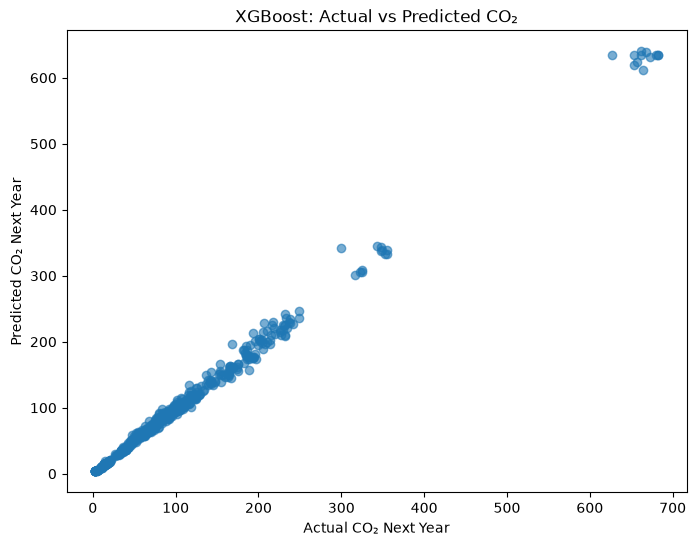

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual CO₂ Next Year")
plt.ylabel("Predicted CO₂ Next Year")
plt.title("XGBoost: Actual vs Predicted CO₂")

plt.show()

In [26]:
trained_xgb = model.named_steps["regressor"]

In [27]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [28]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_xgb.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
56,numeric__co2_lag_1,0.718895
54,numeric__industrial_billion_btu,0.129385
57,numeric__co2_lag_2,0.115121
43,state__state_TX,0.023827
55,numeric__transportation_billion_btu,0.001429
4,state__state_CA,0.001401
51,numeric__year,0.001066
59,numeric__co2_growth_rate,0.001058
52,numeric__residential_billion_btu,0.000669
38,state__state_PA,0.000546


In [29]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_xgb.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
56,numeric__co2_lag_1,0.718895
54,numeric__industrial_billion_btu,0.129385
57,numeric__co2_lag_2,0.115121
43,state__state_TX,0.023827
55,numeric__transportation_billion_btu,0.001429
4,state__state_CA,0.001401
51,numeric__year,0.001066
59,numeric__co2_growth_rate,0.001058
52,numeric__residential_billion_btu,0.000669
38,state__state_PA,0.000546


In [30]:
import joblib

joblib.dump(
    model,
    "../models/xgb_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [31]:
results.to_csv(
    "../outputs/regression/predictions.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\outputs\regression'

In [32]:
with open(
    "../outputs/regression/metrics.txt",
    "w"
) as f:
    f.write("XGBoost Regression Results\n")
    f.write("==========================\n")
    f.write(f"MAE  : {mae}\n")
    f.write(f"RMSE : {rmse}\n")
    f.write(f"R2   : {r2}\n")

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/regression/metrics.txt'

In [33]:
results.to_csv(
    "../outputs/regression/predictions.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\outputs\regression'

In [34]:
results.to_csv(
    "../outputs/regression/predictions.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\outputs\regression'

In [35]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs/regression")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [36]:
results.to_csv(
    OUTPUT_DIR / "predictions.csv",
    index=False
)

In [37]:
with open(OUTPUT_DIR / "metrics.txt", "w") as f:
    f.write("XGBoost Regression Results\n")
    f.write("==========================\n")
    f.write(f"MAE  : {mae}\n")
    f.write(f"RMSE : {rmse}\n")
    f.write(f"R2   : {r2}\n")

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("XGBoost Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

XGBoost Regression Performance
--------------------------------
MAE  : 4.7904
RMSE : 8.2262
R²   : 0.9939
MAPE : 5.67%


In [1]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

train_r2 = r2_score(y_train, train_pred)

train_mape = np.mean(
    np.abs((y_train - train_pred) / y_train)
) * 100

print("XGBoost Training Performance")
print("--------------------------------")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")
print(f"MAPE : {train_mape:.2f}%")

NameError: name 'model' is not defined

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================
# 1. LOAD MODEL AND DATA
# ============================================

model = joblib.load("../models/xgb_regression.pkl")

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

target = "co2_next_year"

# ============================================
# 2. RECREATE CHRONOLOGICAL TRAIN/TEST SPLIT
# ============================================

# Use the same 80/20 chronological split
unique_years = sorted(df["year"].unique())

split_index = int(len(unique_years) * 0.8)

train_years = unique_years[:split_index]
test_years = unique_years[split_index:]

train_df = df[df["year"].isin(train_years)]
test_df = df[df["year"].isin(test_years)]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# ============================================
# 3. PREDICTIONS
# ============================================

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# ============================================
# 4. FUNCTION FOR METRICS
# ============================================

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mae, rmse, r2, mape


# ============================================
# 5. TRAIN METRICS
# ============================================

train_mae, train_rmse, train_r2, train_mape = \
    calculate_metrics(y_train, train_pred)


# ============================================
# 6. TEST METRICS
# ============================================

test_mae, test_rmse, test_r2, test_mape = \
    calculate_metrics(y_test, test_pred)


# ============================================
# 7. DISPLAY RESULTS
# ============================================

print("XGBoost Regression - Train vs Test")
print("====================================")

print("\nTRAINING PERFORMANCE")
print("---------------------")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")
print(f"MAPE : {train_mape:.2f}%")

print("\nTEST PERFORMANCE")
print("----------------")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")
print(f"MAPE : {test_mape:.2f}%")

# ============================================
# 8. GENERALIZATION GAP
# ============================================

print("\nGENERALIZATION GAP")
print("-------------------")

print(
    f"R² gap   : {train_r2 - test_r2:.4f}"
)

print(
    f"MAE gap  : {test_mae - train_mae:.4f}"
)

print(
    f"RMSE gap : {test_rmse - train_rmse:.4f}"
)

print(
    f"MAPE gap : {test_mape - train_mape:.2f}%"
)

XGBoost Regression - Train vs Test

TRAINING PERFORMANCE
---------------------
MAE  : 1.1423
RMSE : 1.5544
R²   : 0.9998
MAPE : 2.25%

TEST PERFORMANCE
----------------
MAE  : 4.5011
RMSE : 7.9112
R²   : 0.9943
MAPE : 5.41%

GENERALIZATION GAP
-------------------
R² gap   : 0.0055
MAE gap  : 3.3588
RMSE gap : 6.3568
MAPE gap : 3.16%


In [3]:
import pandas as pd
import numpy as np

# Load the regression dataset
df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

# Sort chronologically within each state
df = df.sort_values(["state", "year"]).reset_index(drop=True)

print("Dataset shape:", df.shape)

# ============================================
# 1. CHECK TARGET RELATIONSHIPS
# ============================================

print("\nCorrelation with target:")
print("--------------------------------")

correlations = (
    df.select_dtypes(include=np.number)
      .corr()["co2_next_year"]
      .sort_values(ascending=False)
)

print(correlations)


# ============================================
# 2. VERIFY LAG FEATURE CONSTRUCTION
# ============================================

print("\nChecking lag features...")
print("--------------------------------")

lag_check = df.groupby("state").apply(
    lambda x: pd.DataFrame({
        "year": x["year"],
        "co2_lag_1": x["co2_lag_1"],
        "co2_lag_2": x["co2_lag_2"]
    })
).reset_index(drop=True)

print(lag_check.head(10))


# ============================================
# 3. CHECK FOR EXACT TARGET LEAKAGE
# ============================================

print("\nExact leakage checks:")
print("--------------------------------")

for feature in df.columns:

    if feature == "co2_next_year":
        continue

    if df[feature].equals(df["co2_next_year"]):
        print("POSSIBLE LEAKAGE:", feature)


# ============================================
# 4. CHECK WHETHER LAG-1 IS ACTUALLY
#    PREVIOUS-YEAR CO2
# ============================================

print("\nLag-1 verification:")
print("--------------------------------")

df["previous_year_co2"] = (
    df.groupby("state")["co2_next_year"]
      .shift(1)
)

# Note:
# This is only a structural diagnostic.
# It does NOT assume co2_next_year itself is the original
# current-year CO2 column.

comparison = df[
    ["state", "year", "co2_lag_1", "previous_year_co2"]
].dropna()

print(comparison.head(10))


# ============================================
# 5. CHECK DUPLICATES
# ============================================

print("\nDuplicate check:")
print("--------------------------------")

duplicates = df.duplicated(
    subset=["state", "year"]
).sum()

print("Duplicate state-year rows:", duplicates)


# ============================================
# 6. CHECK FUTURE INFORMATION
# ============================================

print("\nFuture-information check:")
print("--------------------------------")

print(
    "Target: co2_next_year"
)

print(
    "Features used for prediction:"
)

features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

for feature in features:
    print(" -", feature)

print("\nValidation complete.")

Dataset shape: (3162, 11)

Correlation with target:
--------------------------------
co2_next_year                 1.000000
co2_lag_1                     0.996371
co2_lag_2                     0.994625
industrial_billion_btu        0.899685
transportation_billion_btu    0.895472
residential_billion_btu       0.883871
commercial_billion_btu        0.841731
year                          0.088671
energy_growth_rate           -0.046689
co2_growth_rate              -0.052526
Name: co2_next_year, dtype: float64

Checking lag features...
--------------------------------
   year  co2_lag_1  co2_lag_2
0  1962      4.846      4.040
1  1963      5.327      4.846
2  1964      5.366      5.327
3  1965      5.620      5.366
4  1966      5.720      5.620
5  1967      6.812      5.720
6  1968      7.801      6.812
7  1969      8.170      7.801
8  1970     10.014      8.170
9  1971     11.356     10.014

Exact leakage checks:
--------------------------------

Lag-1 verification:
-----------------------

In [4]:
import pandas as pd

df = pd.read_excel("../data/processed/CarbonOpt_XGBoost_Regression.xlsx")

df = df.sort_values(["state", "year"]).reset_index(drop=True)

print("Columns:")
print(df.columns.tolist())

print("\nFirst 15 rows:")
print(
    df[
        [
            "state",
            "year",
            "co2_lag_1",
            "co2_lag_2",
            "co2_next_year"
        ]
    ].head(15)
)

PermissionError: [Errno 13] Permission denied: '../data/processed/CarbonOpt_XGBoost_Regression.xlsx'

In [5]:
import pandas as pd
from pathlib import Path

file_path = Path("../data/processed/CarbonOpt_XGBoost_Regression.xlsx").resolve()

print("Trying to read:")
print(file_path)
print("Exists:", file_path.exists())

df = pd.read_excel(
    file_path,
    engine="openpyxl"
)

df = df.sort_values(["state", "year"]).reset_index(drop=True)

print("\nLoaded successfully")
print("Shape:", df.shape)
print(df.head(10))

Trying to read:
C:\Users\angel\OneDrive\Desktop\carbonOPT\data\processed\CarbonOpt_XGBoost_Regression.xlsx
Exists: True


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\angel\\OneDrive\\Desktop\\carbonOPT\\data\\processed\\CarbonOpt_XGBoost_Regression.xlsx'

In [6]:
from pathlib import Path
import os

file_path = Path("../data/processed/CarbonOpt_XGBoost_Regression.xlsx").resolve()

print("Path:", file_path)
print("Exists:", file_path.exists())
print("Is file:", file_path.is_file())

if file_path.exists():
    print("Size:", file_path.stat().st_size, "bytes")
    print("Readable:", os.access(file_path, os.R_OK))

Path: C:\Users\angel\OneDrive\Desktop\carbonOPT\data\processed\CarbonOpt_XGBoost_Regression.xlsx
Exists: True
Is file: True
Size: 265752 bytes
Readable: True


In [7]:
from pathlib import Path
import shutil
import pandas as pd

source = Path("../data/processed/CarbonOpt_XGBoost_Regression.xlsx").resolve()
local_copy = Path("CarbonOpt_validation_copy.xlsx").resolve()

shutil.copy2(source, local_copy)

print("Copy created:")
print(local_copy)
print("Exists:", local_copy.exists())

df = pd.read_excel(local_copy, engine="openpyxl")

df = df.sort_values(["state", "year"]).reset_index(drop=True)

print("\nSuccessfully loaded!")
print("Shape:", df.shape)
print(df[
    ["state", "year", "co2_lag_1", "co2_lag_2", "co2_next_year"]
].head(15))

Copy created:
C:\Users\angel\OneDrive\Desktop\carbonOPT\notebooks\CarbonOpt_validation_copy.xlsx
Exists: True

Successfully loaded!
Shape: (3162, 11)
   state  year  co2_lag_1  co2_lag_2  co2_next_year
0     AK  1962      4.846      4.040          5.366
1     AK  1963      5.327      4.846          5.620
2     AK  1964      5.366      5.327          5.720
3     AK  1965      5.620      5.366          6.812
4     AK  1966      5.720      5.620          7.801
5     AK  1967      6.812      5.720          8.170
6     AK  1968      7.801      6.812         10.014
7     AK  1969      8.170      7.801         11.356
8     AK  1970     10.014      8.170         12.643
9     AK  1971     11.356     10.014         13.432
10    AK  1972     12.643     11.356         12.505
11    AK  1973     13.432     12.643         12.791
12    AK  1974     12.505     13.432         14.540
13    AK  1975     12.791     12.505         15.978
14    AK  1976     14.540     12.791         17.966


In [8]:
# ============================================================
# FINAL LAG / LEAKAGE VALIDATION
# ============================================================

import pandas as pd
import numpy as np

# Load the local copy
df = pd.read_excel("CarbonOpt_validation_copy.xlsx", engine="openpyxl")

df = df.sort_values(["state", "year"]).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Check whether lag values move correctly between years
# ------------------------------------------------------------

df["expected_lag_2"] = (
    df.groupby("state")["co2_lag_1"].shift(1)
)

lag2_matches = np.isclose(
    df["co2_lag_2"],
    df["expected_lag_2"],
    equal_nan=True
)

print("=" * 60)
print("LAG-2 CONSISTENCY CHECK")
print("=" * 60)

print("Matching rows:", lag2_matches.sum())
print("Total rows:", len(df))
print(
    "Match percentage:",
    round(lag2_matches.mean() * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 2. Check whether co2_next_year is simply the next row's
#    co2_lag_1
# ------------------------------------------------------------

df["expected_next_co2"] = (
    df.groupby("state")["co2_lag_1"].shift(-1)
)

next_matches = np.isclose(
    df["co2_next_year"],
    df["expected_next_co2"],
    equal_nan=True
)

print("\n" + "=" * 60)
print("TARGET ALIGNMENT CHECK")
print("=" * 60)

print("Matching rows:", next_matches.sum())
print("Total rows:", len(df))
print(
    "Match percentage:",
    round(next_matches.mean() * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 3. Show examples where the relationships are visible
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE VERIFICATION")
print("=" * 60)

print(
    df[
        [
            "state",
            "year",
            "co2_lag_2",
            "co2_lag_1",
            "co2_next_year",
            "expected_lag_2",
            "expected_next_co2"
        ]
    ].head(15)
)

# ------------------------------------------------------------
# 4. Check exact target leakage
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DIRECT TARGET LEAKAGE CHECK")
print("=" * 60)

for feature in [
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]:
    identical = df[feature].equals(df["co2_next_year"])
    print(f"{feature:30} identical to target: {identical}")

# ------------------------------------------------------------
# 5. Check duplicate state-year records
# ------------------------------------------------------------

duplicates = df.duplicated(
    subset=["state", "year"]
).sum()

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print("Duplicate state-year rows:", duplicates)

LAG-2 CONSISTENCY CHECK
Matching rows: 3111
Total rows: 3162
Match percentage: 98.39 %

TARGET ALIGNMENT CHECK
Matching rows: 3
Total rows: 3162
Match percentage: 0.09 %

SAMPLE VERIFICATION
   state  year  co2_lag_2  co2_lag_1  co2_next_year  expected_lag_2  \
0     AK  1962      4.040      4.846          5.366             NaN   
1     AK  1963      4.846      5.327          5.620           4.846   
2     AK  1964      5.327      5.366          5.720           5.327   
3     AK  1965      5.366      5.620          6.812           5.366   
4     AK  1966      5.620      5.720          7.801           5.620   
5     AK  1967      5.720      6.812          8.170           5.720   
6     AK  1968      6.812      7.801         10.014           6.812   
7     AK  1969      7.801      8.170         11.356           7.801   
8     AK  1970      8.170     10.014         12.643           8.170   
9     AK  1971     10.014     11.356         13.432          10.014   
10    AK  1972     11.356   

In [ ]:
from pathlib import Path
import re

# Search the whole carbonOPT project
root = Path("..")

patterns = [
    "co2_next_year",
    "co2_lag_1",
    "co2_lag_2",
    "shift(-1)",
    "shift(1)"
]

for file in root.rglob("*"):
    if not file.is_file():
        continue

    if file.suffix.lower() not in [".py", ".ipynb"]:
        continue

    try:
        text = file.read_text(encoding="utf-8")
    except:
        continue

    matches = [p for p in patterns if p in text]

    if matches:
        print("\n" + "=" * 80)
        print("FILE:", file)
        print("FOUND:", matches)
        print("=" * 80)

        # Show lines containing the important terms
        for i, line in enumerate(text.splitlines(), 1):
            if any(p in line for p in patterns):
                print(f"{i}: {line}")


FILE: ..\notebooks\01_XGBoost_Regression.ipynb
FOUND: ['co2_next_year', 'co2_lag_1', 'co2_lag_2', 'shift(-1)', 'shift(1)']
92:        "      <th>co2_lag_1</th>\n",
93:        "      <th>co2_lag_2</th>\n",
96:        "      <th>co2_next_year</th>\n",
182:        "   industrial_billion_btu  transportation_billion_btu  co2_lag_1  co2_lag_2  \\\n",
189:        "   energy_growth_rate  co2_growth_rate  co2_next_year  \n",
221:        " 'co2_lag_1',\n",
222:        " 'co2_lag_2',\n",
225:        " 'co2_next_year']"
247:       "['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate', 'co2_next_year']\n"
277:        "      <th>co2_lag_1</th>\n",
278:        "      <th>co2_lag_2</th>\n",
281:        "      <th>co2_next_year</th>\n",
442:        "   industrial_billion_btu  transportation_billion_btu  co2_lag_1  co2_lag_2  \\\n",
454:        "   energy_growth_ra

In [1]:
import json
from pathlib import Path

nb_path = Path("../notebooks/01_XGBoost_Regression.ipynb")

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"], start=1):
    source = "".join(cell.get("source", []))

    if "shift(" in source or "co2_lag_" in source or "co2_next_year" in source:
        print("\n" + "=" * 80)
        print(f"CELL {i} | {cell['cell_type']}")
        print("=" * 80)
        print(source)


CELL 6 | code
y = df["co2_next_year"]

CELL 7 | code
X = df.drop(columns=["co2_next_year"])

CELL 11 | code
feature_columns = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

target_column = "co2_next_year"

CELL 14 | code
categorical_features = ["state"]

numeric_features = [
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

CELL 21 | code
results = test_df[
    ["state", "year", "co2_next_year"]
].copy()

results["predicted_co2_next_year"] = y_pred

results.head(10)

CELL 39 | code
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#

In [2]:
import json
from pathlib import Path

nb_path = Path("../notebooks/01_XGBoost_Regression.ipynb")

with open(nb_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"][:10], start=1):
    print("\n" + "=" * 80)
    print(f"CELL {i} | {cell['cell_type']}")
    print("=" * 80)
    print("".join(cell.get("source", [])))


CELL 1 | code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

print("Libraries loaded successfully.")

CELL 2 | code
file_path = "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)

CELL 3 | code
df.head()

CELL 4 | code
df.columns.tolist()

CELL 5 | code
print(df.columns.tolist())
display(df.head(10))

CELL 6 | code
y = df["co2_next_year"]

CELL 7 | code
X = df.drop(columns=["co2_next_year"])

CELL 8 | code
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nYear range:")
print(df["year"].min(), "to", df["year"].max())


CELL 9 | code
years = sor

In [3]:
print("".join(nb["cells"][1].get("source", [])))

file_path = "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
